In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LeakyReLU
from tensorflow.keras.optimizers import SGD, Adam, RMSprop

In [2]:
housing = fetch_california_housing()

X = housing.data
y = housing.target

print("Features shape:", X.shape)
print("Target shape:", y.shape)

df = pd.DataFrame(X, columns=housing.feature_names)
df["Price"] = y

df.head()

Features shape: (20640, 8)
Target shape: (20640,)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [4]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [5]:
def build_model(activation_name="relu", optimizer_name="adam"):

    model = Sequential()

    # Input layer
    model.add(Dense(64, input_shape=(X_train.shape[1],)))

    if activation_name == "relu":
        model.add(tf.keras.layers.ReLU())

    elif activation_name == "leakyrelu":
        model.add(LeakyReLU(alpha=0.1))

    elif activation_name == "elu":
        model.add(tf.keras.layers.ELU(alpha=1.0))

    # Hidden Layer
    model.add(Dense(32))

    if activation_name == "relu":
        model.add(tf.keras.layers.ReLU())

    elif activation_name == "leakyrelu":
        model.add(LeakyReLU(alpha=0.1))

    elif activation_name == "elu":
        model.add(tf.keras.layers.ELU(alpha=1.0))

    # Output layer
    model.add(Dense(1))

    if optimizer_name == "sgd":
        optimizer = SGD(learning_rate=0.01)

    elif optimizer_name == "adam":
        optimizer = Adam()

    elif optimizer_name == "rmsprop":
        optimizer = RMSprop()

    model.compile(
        optimizer=optimizer,
        loss="mse",
        metrics=["mae"]
    )

    return model

In [6]:
activations = ["relu", "leakyrelu", "elu"]
optimizers = ["sgd", "adam", "rmsprop"]

results = {}

histories = {}

In [7]:
for act in activations:
    for opt in optimizers:

        print(f"\nTraining: {act.upper()} + {opt.upper()}")

        model = build_model(act, opt)

        history = model.fit(
            X_train,
            y_train,
            validation_split=0.2,
            epochs=50,
            batch_size=32,
            verbose=0
        )

        pred = model.predict(X_test, verbose=0)

        rmse = np.sqrt(mean_squared_error(y_test, pred))

        key = f"{act}_{opt}"

        results[key] = rmse
        histories[key] = history

        print("RMSE:", round(rmse,4))


Training: RELU + SGD


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


RMSE: 0.5394

Training: RELU + ADAM


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


RMSE: 0.5376

Training: RELU + RMSPROP


...

RMSE: 0.5925

Training: ELU + ADAM


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


RMSE: 0.562

Training: ELU + RMSPROP


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


RMSE: 0.5559


In [8]:
rmse_table = pd.DataFrame(
    results.items(),
    columns=["Configuration","RMSE"]
)

rmse_table = rmse_table.sort_values("RMSE")

rmse_table

,Configuration,RMSE
4,leakyrelu_adam,0.533463
2,relu_rmsprop,0.533526
1,relu_adam,0.537633
0,relu_sgd,0.539359
5,leakyrelu_rmsprop,0.545119
3,leakyrelu_sgd,0.552397
8,elu_rmsprop,0.555853
7,elu_adam,0.561950
6,elu_sgd,0.592532


In [9]:
best_model = rmse_table.iloc[0]

print("Best Configuration:")
print(best_model)

Best Configuration:
Configuration    leakyrelu_adam
RMSE                   0.533463
Name: 4, dtype: object


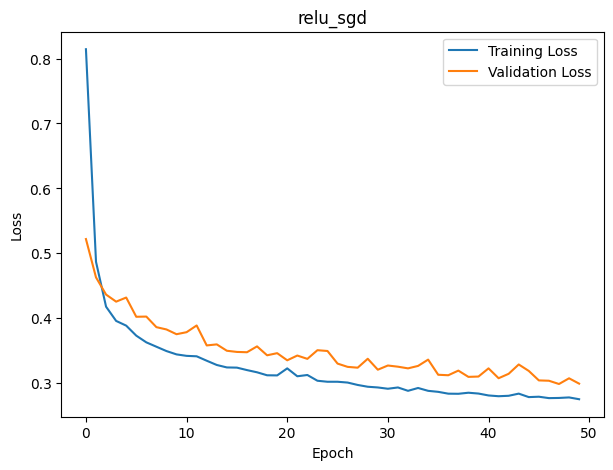

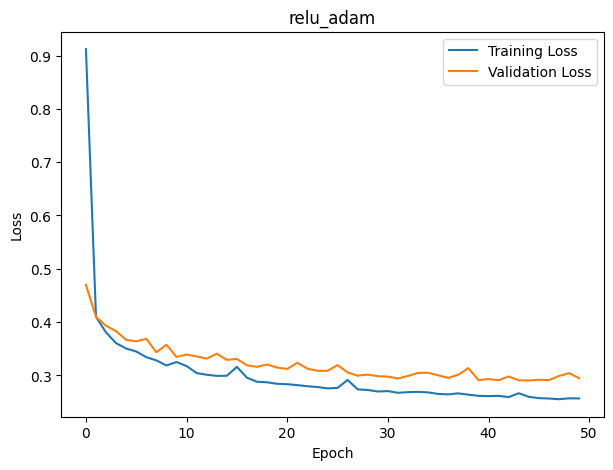

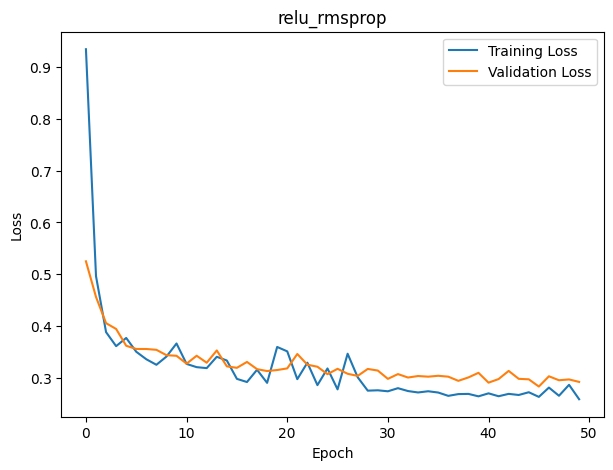

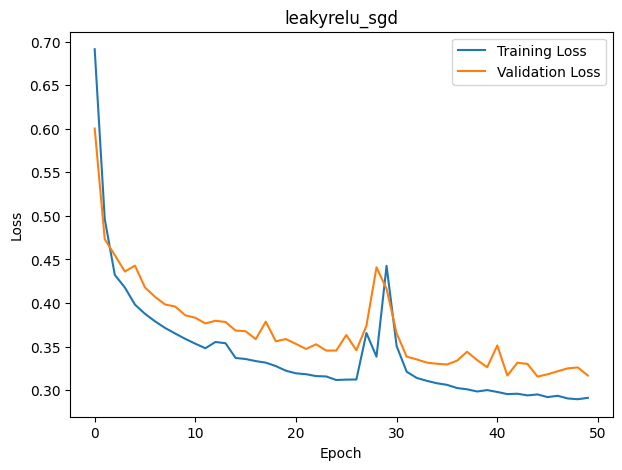

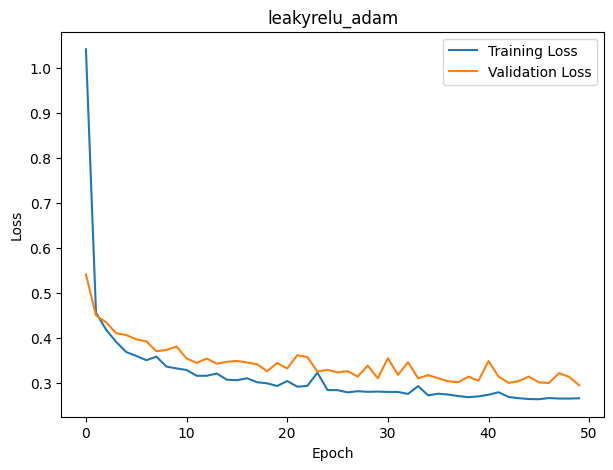

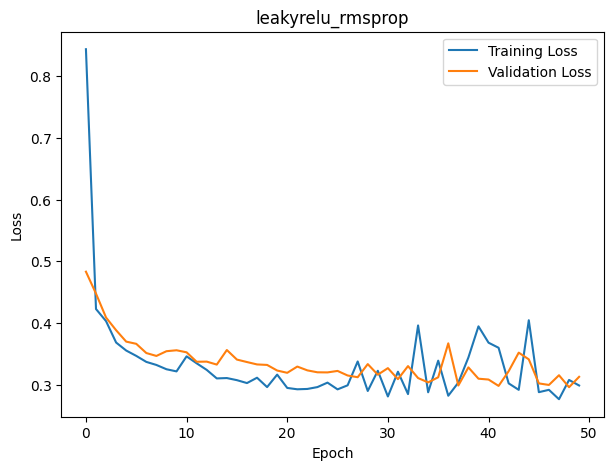

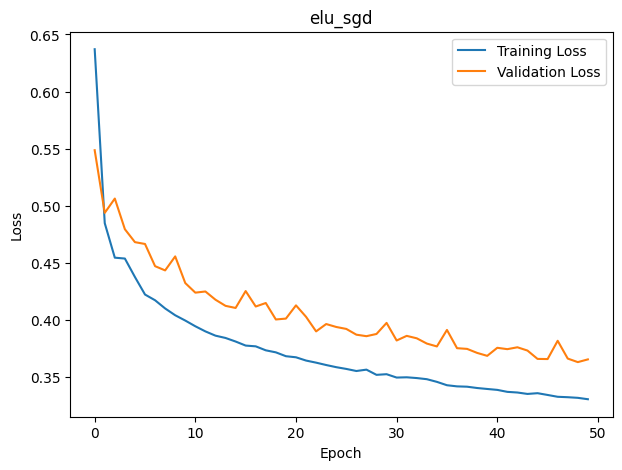

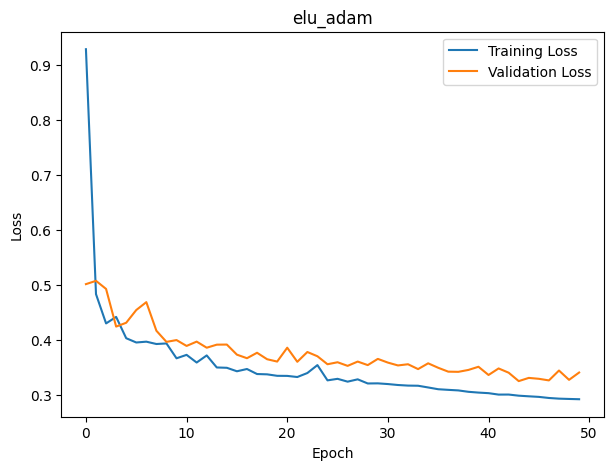

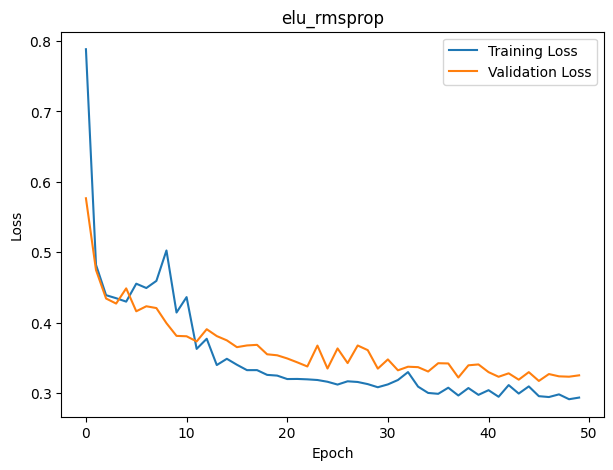

In [10]:
for key, history in histories.items():

    plt.figure(figsize=(7,5))

    plt.plot(history.history["loss"], label="Training Loss")
    plt.plot(history.history["val_loss"], label="Validation Loss")

    plt.title(key)
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()

    plt.show()

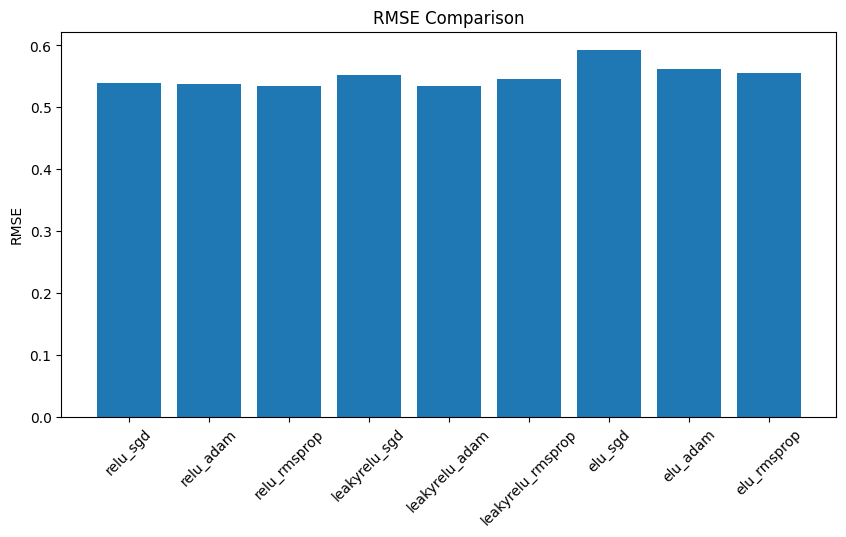

In [11]:
plt.figure(figsize=(10,5))

plt.bar(results.keys(), results.values())

plt.xticks(rotation=45)

plt.ylabel("RMSE")

plt.title("RMSE Comparison")

plt.show()

In [12]:
rmse_table.reset_index(drop=True, inplace=True)

rmse_table

,Configuration,RMSE
0,leakyrelu_adam,0.533463
1,relu_rmsprop,0.533526
2,relu_adam,0.537633
3,relu_sgd,0.539359
4,leakyrelu_rmsprop,0.545119
5,leakyrelu_sgd,0.552397
6,elu_rmsprop,0.555853
7,elu_adam,0.561950
8,elu_sgd,0.592532
